# بسم الله الرحمن الرحیم

## 1-  آماده‌سازی دیتاست 

In [27]:
import os
import zipfile
from pathlib import Path

# ریشه پروژه (نسبت به نوت‌بوک)
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ACDC_ZIP = DATA_DIR / "ACDC_archive.zip"  # اگر اسم دیگری گذاشتی، همین‌جا اصلاح کن
ACDC_DIR = DATA_DIR / "ACDC"

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)

# اگر پوشه ACDC وجود ندارد، بساز
ACDC_DIR.mkdir(parents=True, exist_ok=True)

# اگر zip وجود دارد و پوشه خالی است، unzip کن
if ACDC_ZIP.exists():
    # چک کنیم که پوشه تقریباً خالی است
    if not any(ACDC_DIR.iterdir()):
        print("Extracting ACDC_archive.zip ...")
        with zipfile.ZipFile(ACDC_ZIP, 'r') as zf:
            zf.extractall(ACDC_DIR)
        print("Done.")
    else:
        print("ACDC directory is not empty; skip extraction.")
else:
    print("ZIP file not found:", ACDC_ZIP)


Project root: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D
Data dir: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data
ACDC directory is not empty; skip extraction.


PROJECT_ROOT: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D
DATA_DIR: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database
TRAIN_DIR: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database\training
تعداد بیماران در پوشه آموزش: 100
First 5 patients: ['patient001', 'patient002', 'patient003', 'patient004', 'patient005']
 ----- 
Using patient: patient001
Image path: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database\training\patient001\patient001_frame01.nii
GT path   : C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database\training\patient001\patient001_frame01_gt.nii
Image shape: (216, 256, 10)
GT shape   : (216, 256, 10)
-----
Voxel spacing (mm): (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))
Slice index: 5


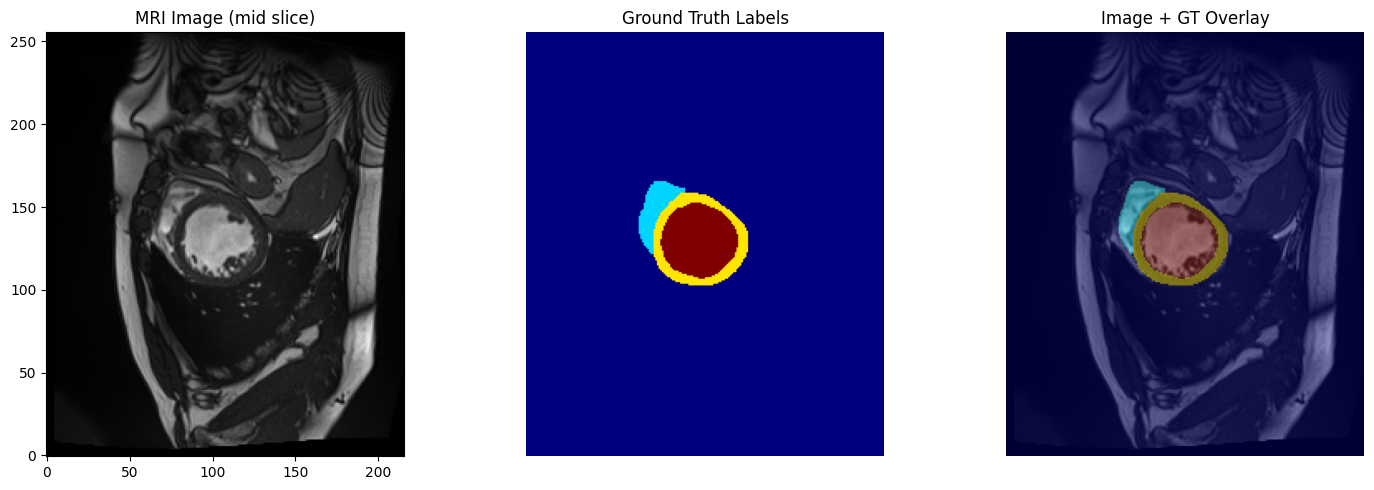

In [28]:
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# 1. مسیرها را تنظیم می‌کنیم
PROJECT_ROOT = Path("..").resolve()
# os.path.join(PROJECT_ROOT, "data", "ACDC")
DATA_DIR = PROJECT_ROOT / "data" / "ACDC" / "database"    # حواسمان به پوشه بندی باشد
TRAIN_DIR = DATA_DIR / "training"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("TRAIN_DIR:", TRAIN_DIR)

# 2. لیست بیماران موجود در training
patients = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir()])    # حلقه 
# همه محتویات پوشه آموزش را بر می گرداند

# print(f"Number of patients in training: {len(patients)}")
print(f"تعداد بیماران در پوشه آموزش: {len(patients)}")
print("First 5 patients:", [p.name for p in patients[:5]])

print(" ----- ")
# 3. انتخاب اولین بیمار (مثلاً patient001)
patient_dir = patients[0]
# patient_dir = patients[2]  # انتخاب بیمار سوم (patient003) برای مثال
# pateint_dir = patients[1]  # انتخاب بیمار دوم (patient002) برای مثال
# print("Selected patient directory:", patient_dir)
print("Using patient:", patient_dir.name)

# 4. پیدا کردن فایل‌های فریم و ماسک (frame01)
img_path = patient_dir / f"{patient_dir.name}_frame01.nii"  # با f-string نام فایل ها را می سازیم
gt_path = patient_dir / f"{patient_dir.name}_frame01_gt.nii"

# مسیر را هاردکد نمی‌کنیم ، بخاطر همین روی بیماران 2و3 نیز قابل اجرا است
print("Image path:", img_path)
print("GT path   :", gt_path)

# 5. لود کردن با nibabel
img_nii = nib.load(str(img_path))
gt_nii = nib.load(str(gt_path))

img = img_nii.get_fdata()       # داده‌ی تصویری (float64)
gt  = gt_nii.get_fdata()        # داده‌ی برچسب‌ها (عدد صحیح)

print("Image shape:", img.shape)
print("GT shape   :", gt.shape)

print("-----")
# 6. استخراج اطلاعات spacing (voxel size)
voxel_spacing = img_nii.header.get_zooms()  # (dx, dy, dz)
print("Voxel spacing (mm):", voxel_spacing)

# 7. یک اسلایس میانی را برای نمایش انتخاب می‌کنیم
slice_idx = img.shape[-1] // 2  # فرض بر این است که محور سوم، محور اسلایس است

img_slice = img[:, :, slice_idx]
gt_slice  = gt[:, :, slice_idx]

print("Slice index:", slice_idx)

# 8. نرمال‌سازی ساده برای نمایش (اختیاری است ، میتواند انجام نگیرد)
img_slice_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

# 9. رسم تصویر، ماسک و ترکیب‌شان
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# براین که NIfTi محور هایش برعکس ضار می شوند، 
# برای ترانهاده کردن تصویر و ماسک، از .T استفاده می کنیم
axes[0].imshow(img_slice_norm.T, cmap="gray", origin="lower") 
axes[0].set_title("MRI Image (mid slice)")
# axes[0].axis("off")

axes[1].imshow(gt_slice.T, cmap="jet", origin="lower")
axes[1].set_title("Ground Truth Labels")
axes[1].axis("off")

axes[2].imshow(img_slice_norm.T, cmap="gray", origin="lower")
axes[2].imshow(gt_slice.T, cmap="jet", alpha=0.4, origin="lower")
axes[2].set_title("Image + GT Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## ۲ – بررسی کلاس‌های ماسک و visualization چند بیمار

یک فریم (مثلاً frame01) و ground-truth آن را برای یک بیمار ACDC برمی‌گرداند.

Parameters
----------
patient_dir : Path
    مسیر پوشه‌ی بیمار (مثل .../training/patient001)
frame : int
    شماره فریم (۱ یا ۱۲ معمولاً مهم‌ترین‌ها هستند: ED و ES)

Returns
-------
img : np.ndarray
    حجم MRI با شکل (H, W, Slices)
gt : np.ndarray
    ماسک برچسب‌ها با همان شکل img
img_nii, gt_nii : nib.Nifti1Image
    آبجکت‌های NIfTI برای دسترسی به header و meta-data


Patient: patient001
Image shape: (216, 256, 10)
Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))
Unique label values in GT: [0. 1. 2. 3.]


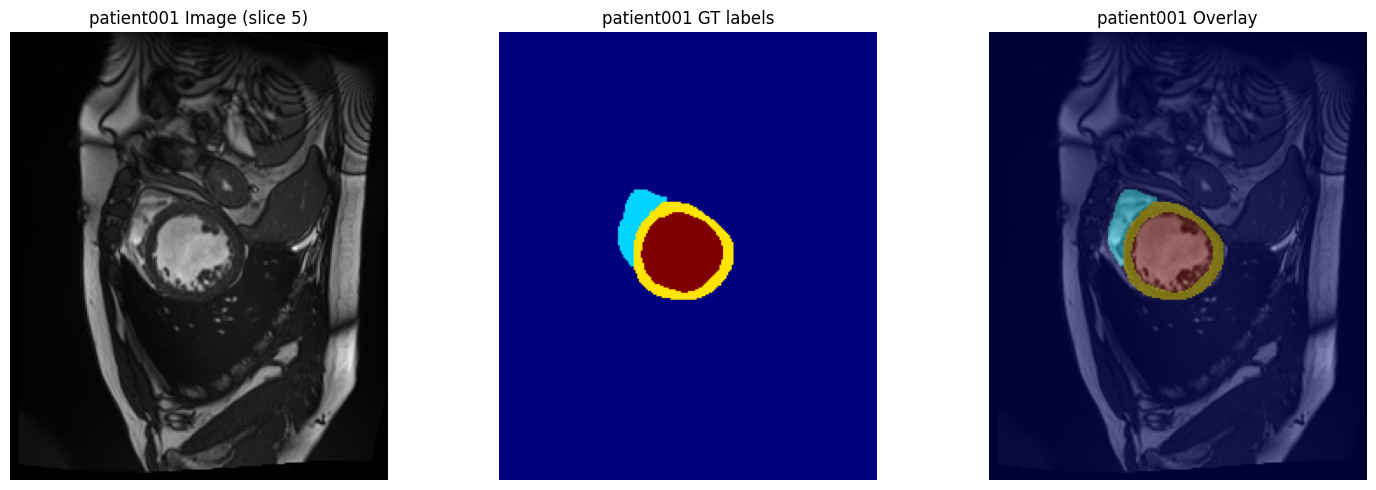

Patient: patient002
Image shape: (232, 256, 10)
Voxel spacing: (np.float32(1.3671875), np.float32(1.3671875), np.float32(10.0))
Unique label values in GT: [0. 1. 2. 3.]


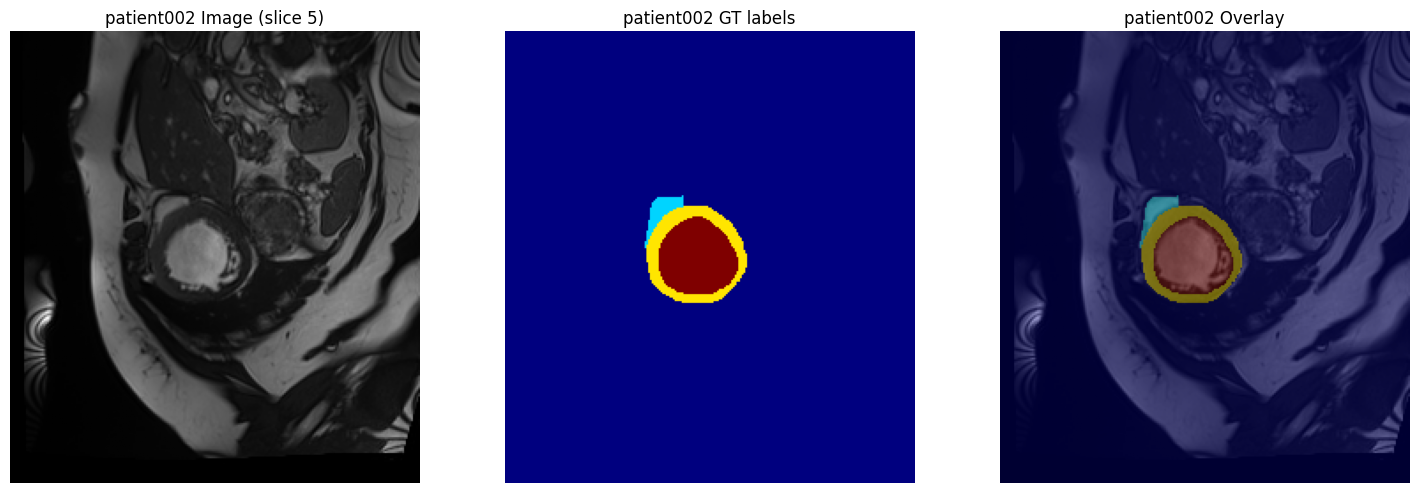

Patient: patient003
Image shape: (256, 256, 10)
Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))
Unique label values in GT: [0. 1. 2. 3.]


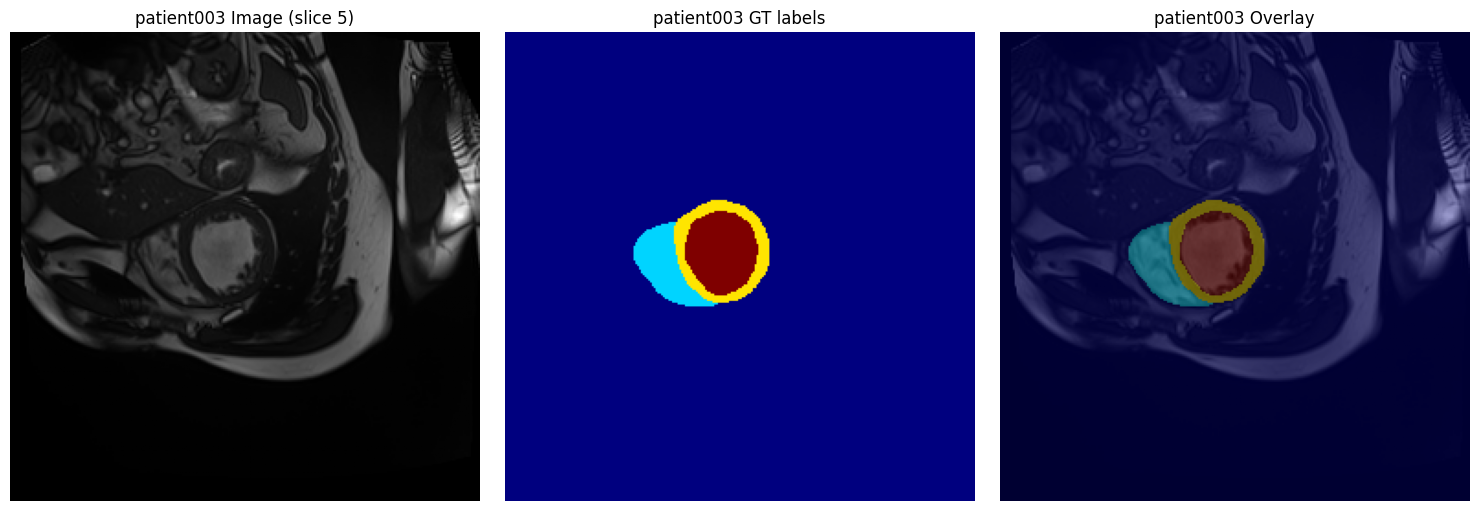

In [29]:
def load_acdc_frame(patient_dir: Path, frame: int = 1):
    """
    تلاش می‌کند فریم مشخص (مثلاً frame01) و GT آن را برای یک بیمار ACDC لود کند.
    اگر فایل‌ها وجود نداشته باشند، None برمی‌گرداند.
    """
    """
    Try to load a specific frame (e.g., frame01) and its GT for an ACDC patient.
    If the files do not exist, return "None".
    """
    frame_str = f"{frame:02d}"  # 1 -> "01"
    base_name = patient_dir.name  # مثلا 'patient001'
    
    img_path = patient_dir / f"{base_name}_frame{frame_str}.nii"
    gt_path  = patient_dir / f"{base_name}_frame{frame_str}_gt.nii"
    
    if not img_path.exists() or not gt_path.exists():
        # قبل از لود کردن با nib.load، چک می‌کنیم که فایل‌ها واقعاً روی دیسک وجود داشته باشند؛
        # این کار از خطای FileNotFoundError جلوگیری می‌کند.
        print(f"[WARN] frame{frame_str} files not found for {base_name}")
        return None, None, None, None
    
    img_nii = nib.load(str(img_path))
    gt_nii  = nib.load(str(gt_path))
    
    img = img_nii.get_fdata()
    gt  = gt_nii.get_fdata()
    
    return img, gt, img_nii, gt_nii



def describe_mask_classes(gt: np.ndarray):
    """
    کلاس‌های موجود در ماسک (gt) را چاپ می‌کند.
    """
    """
    Print the unique classes present in the mask (gt).
    """
    unique_vals = np.unique(gt)
    print("Unique label values in GT:", unique_vals)
    return unique_vals


def plot_mid_slice(img: np.ndarray, gt: np.ndarray, title_prefix: str = ""):
    """
    یک اسلایس میانی از img و gt را رسم می‌کند.
    1. تصویر MRI
    2. ماسک GT
    3. ترکیب تصویر و ماسک
    """
    """
    An intermediate slice of img and gt is plotted.
    1. MRI image
    2. GT mask
    3. Overlay of image and mask
    """
    slice_idx = img.shape[-1] // 2
    img_slice = img[:, :, slice_idx]
    gt_slice  = gt[:, :, slice_idx]
    
    img_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_norm.T, cmap="gray", origin="lower")
    axes[0].set_title(f"{title_prefix} Image (slice {slice_idx})")
    axes[0].axis("off")
    
    axes[1].imshow(gt_slice.T, cmap="jet", origin="lower")
    axes[1].set_title(f"{title_prefix} GT labels")
    axes[1].axis("off")
    
    axes[2].imshow(img_norm.T, cmap="gray", origin="lower")
    axes[2].imshow(gt_slice.T, cmap="jet", alpha=0.4, origin="lower")
    axes[2].set_title(f"{title_prefix} Overlay")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()


# حالا از این توابع برای چند بیمار استفاده می‌کنیم
for p in patients[:3]:  # سه بیمار اول
    print("=" * 60)
    print("Patient:", p.name)
    
    img, gt, img_nii, gt_nii = load_acdc_frame(p, frame=1)  # ED frame
    print("Image shape:", img.shape)
    print("Voxel spacing:", img_nii.header.get_zooms())
    
    unique_vals = describe_mask_classes(gt)
    plot_mid_slice(img, gt, title_prefix=p.name)


In [30]:
def count_voxels_per_class(gt: np.ndarray):
    """
    تعداد voxel های هر کلاس در ماسک gt را برمی‌گرداند.
    
    Returns
    -------
    counts : dict
        دیکشنری از {label_value: voxel_count}
    """
    labels, counts = np.unique(gt, return_counts=True)
    result = {int(lbl): int(cnt) for lbl, cnt in zip(labels, counts)}
    return result

# مثال: روی patient001, frame01
patient_example = patients[0]
img_ex, gt_ex, _, _ = load_acdc_frame(patient_example, frame=1)

voxel_counts = count_voxels_per_class(gt_ex)
print("Voxel counts for", patient_example.name, "frame01:", voxel_counts)


Voxel counts for patient001 frame01: {0: 528405, 1: 5723, 2: 6728, 3: 12104}


تعداد voxel های هر کلاس در ماسک gt را برمی‌گرداند.

Parameters
----------
gt : np.ndarray
    آرایه‌ی ماسک که مقادیر کلاس‌ها را (0,1,2,3,...) دارد.

Returns
-------
counts : dict
    دیکشنری از {label_value: voxel_count}


In [31]:
import pandas as pd
from tqdm.auto import tqdm

def count_voxels_per_class(gt: np.ndarray):
    
    labels, counts = np.unique(gt, return_counts=True)
    result = {int(lbl): int(cnt) for lbl, cnt in zip(labels, counts)}
    return result


# 1. شمارش برای همه بیماران (فریم 1)
records = []  # این لیست را بعداً به DataFrame تبدیل می‌کنیم

for p in tqdm(patients, desc="Processing patients (frame01)"):
    img, gt, img_nii, gt_nii = load_acdc_frame(p, frame=1)
    
    ### 
    if img is None or gt is None:
        continue

    voxel_counts = count_voxels_per_class(gt)
    
    # یک رکورد برای این بیمار می‌سازیم
    record = {
        "patient": p.name,
        "shape_H": img.shape[0],
        "shape_W": img.shape[1],
        "shape_S": img.shape[2],
        "dx_mm": float(img_nii.header.get_zooms()[0]),
        "dy_mm": float(img_nii.header.get_zooms()[1]),
        "dz_mm": float(img_nii.header.get_zooms()[2]),
    }
    
    # افزودن تعداد voxel هر کلاس
    for label, cnt in voxel_counts.items():
        record[f"class_{label}_voxels"] = cnt
    
    records.append(record)

# 2. تبدیل به DataFrame
df_frame01 = pd.DataFrame(records)
df_frame01.head()


Processing patients (frame01):  97%|█████████▋| 97/100 [00:01<00:00, 59.79it/s]

[WARN] frame01 files not found for patient090


Processing patients (frame01): 100%|██████████| 100/100 [00:01<00:00, 59.14it/s]


,patient,shape_H,shape_W,shape_S,dx_mm,dy_mm,dz_mm,class_0_voxels,class_1_voxels,class_2_voxels,class_3_voxels
0,patient001,216,256,10,1.562500,1.562500,10.0,528405,5723,6728,12104
1,patient002,232,256,10,1.367188,1.367188,10.0,566068,5052,8583,14217
2,patient003,256,256,10,1.562500,1.562500,10.0,628290,7878,7858,11334
3,patient004,232,256,10,1.367188,1.367188,10.0,565268,5685,9012,13955
4,patient005,256,216,10,1.406250,1.406250,10.0,519451,8620,10184,14705


## خطای فنی 1

FileNotFoundError: No such file or no access: 'C:/Users/MahdiCS313/Downloads/Proposal_Nazanin/ACDC-SAMMed3D/data/ACDC/database/training/patient090/patient090_frame01.nii'
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

یعنی برای بیمار شماره 90 و احتمالا چند بیمار دیگر ، فایل "فریم 1" وجود ندارد - یا نام گذاری متفاویت دارد

* پس برویم و تابع لود_فریم را اصلاح کنیم

In [32]:
print("Number of patients with frame01:", len(df_frame01))

Number of patients with frame01: 99


In [33]:
# Calculate physical volume for each class in mm^3
for i in [1, 2, 3]:
    voxel_col = f"class_{i}_voxels"
    volume_col = f"class_{i}_volume_mm3"
    
    # Volume = counts * (spacing_x * spacing_y * spacing_z)
    df_frame01[volume_col] = df_frame01[voxel_col] * (df_frame01["dx_mm"] * df_frame01["dy_mm"] * df_frame01["dz_mm"])

# Convert to ml (1000 mm^3 = 1 ml) for better clinical interpretation
for i in [1, 2, 3]:
    df_frame01[f"class_{i}_ml"] = df_frame01[f"class_{i}_volume_mm3"] / 1000.0

# Displaying the summary of volumes in ml
volume_stats = df_frame01[["class_1_ml", "class_2_ml", "class_3_ml"]].describe()
print("Volume statistics in milliliters (ml):")
print(volume_stats)


Volume statistics in milliliters (ml):
       class_1_ml  class_2_ml  class_3_ml
count   99.000000   99.000000   99.000000
mean   152.332302  124.419289  165.493623
std     55.042046   48.394847   74.124848
min     47.365570   32.645727   49.267578
25%    111.669922   92.419125  118.824796
50%    151.889832  118.544769  149.658203
75%    181.363594  157.342243  200.515625
max    295.117188  259.052658  374.376419


### کد بررسی شدت تصویر

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def describe_intensity(img: np.ndarray):
    """
    Print basic intensity statistics for an MRI volume.
    """
    img = np.asarray(img)

    stats = {
        "shape": img.shape,
        "dtype": img.dtype,
        "min": float(np.min(img)),
        "max": float(np.max(img)),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
    }

    for k, v in stats.items():
        print(f"{k}: {v}")

    return stats


def plot_intensity_histogram(img: np.ndarray, bins: int = 100, title: str = ""):
    """
    Plot the intensity histogram of a 3D MRI volume.
    """
    img = np.asarray(img)
    values = img[np.isfinite(img)].ravel()

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=bins, color="steelblue", alpha=0.85)
    plt.title(title or "Intensity Histogram")
    plt.xlabel("Intensity")
    plt.ylabel("Voxel Count")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


Patient: patient001
shape: (216, 256, 10)
dtype: float64
min: 0.0
max: 658.0
mean: 77.94703233506945
std: 88.6452010850085


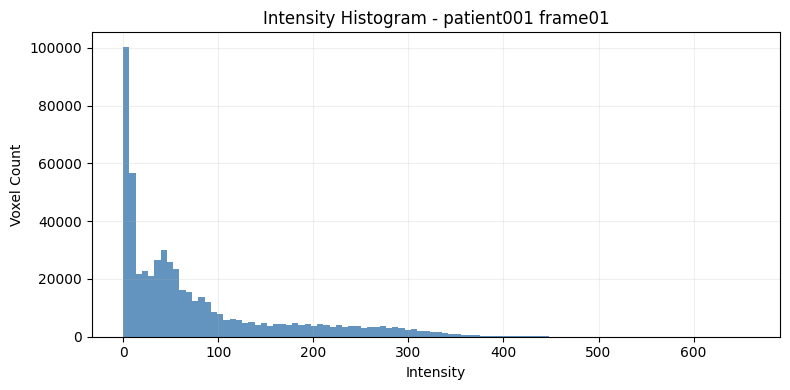

In [35]:
patient_example = patients[0]
img_ex, gt_ex, img_nii_ex, gt_nii_ex = load_acdc_frame(patient_example, frame=1)

print("Patient:", patient_example.name)
describe_intensity(img_ex)
plot_intensity_histogram(img_ex, title=f"Intensity Histogram - {patient_example.name} frame01")


In [36]:
def zscore_normalize(img: np.ndarray, eps: float = 1e-8):
    """
    Normalize a 3D MRI volume using z-score normalization.
    """
    img = np.asarray(img)
    mean = np.mean(img)
    std = np.std(img)

    if std < eps:
        return img * 0.0

    return (img - mean) / (std + eps)


Before normalization:
shape: (216, 256, 10)
dtype: float64
min: 0.0
max: 658.0
mean: 77.94703233506945
std: 88.6452010850085

After normalization:
shape: (216, 256, 10)
dtype: float64
min: -0.8793147443089118
max: 6.543534906568029
mean: -9.950887850343995e-17
std: 0.9999999998871907


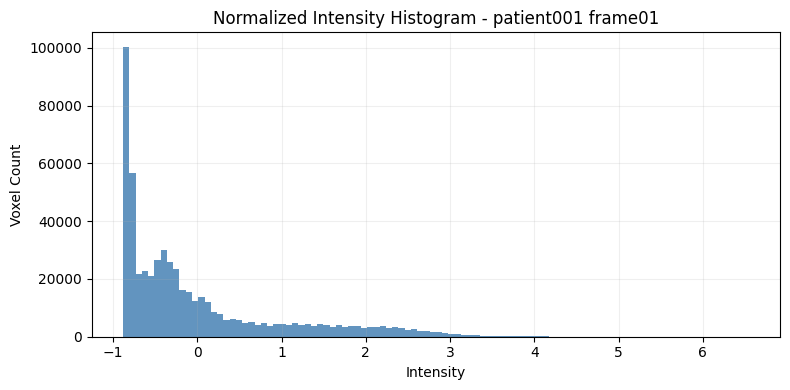

In [37]:
img_norm = zscore_normalize(img_ex)

print("Before normalization:")
describe_intensity(img_ex)

print("\nAfter normalization:")
describe_intensity(img_norm)

plot_intensity_histogram(img_norm, title=f"Normalized Intensity Histogram - {patient_example.name} frame01")


Non-zero normalization:
shape: (216, 256, 10)
dtype: float64
min: -0.9155670430134881
max: 6.456379663923349
mean: -9.128500424695731e-17
std: 0.9714446914577121


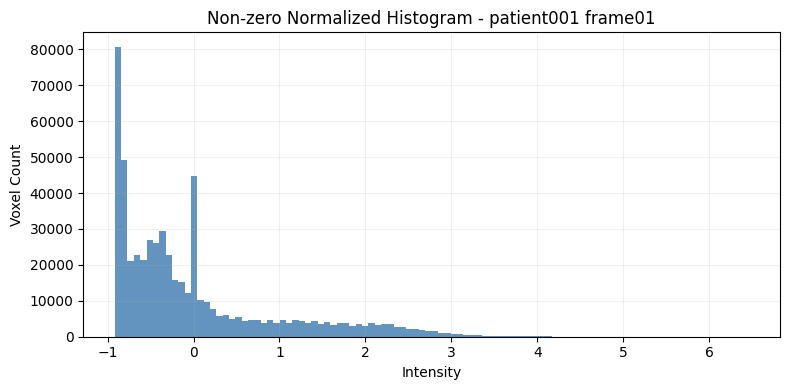

In [38]:
def zscore_normalize_nonzero(img: np.ndarray, eps: float = 1e-8):
    """
    Normalize using only non-zero voxels.
    Background stays zero.
    """
    img = np.asarray(img).copy() # تبدیل ورودی به آرایه نامپای و گرفتن یک کپی مستقل
    mask = img > 0  # ماسک مشخص کننده وکسل های غیر صفر ( نواحی واقعی تصویر ، بدون بک گرانت)

    if not np.any(mask):
        return img * 0.0

    values = img[mask]  # فقط وکسل‌های غیرصفر را جدا می‌کند تا میانگین و انحراف معیار را محاسبه کند
    mean = np.mean(values)
    std = np.std(values)

    if std < eps:
        img[mask] = 0.0
        return img

    img[mask] = (img[mask] - mean) / (std + eps)
    return img


img_norm_nonzero = zscore_normalize_nonzero(img_ex)

print("Non-zero normalization:")
describe_intensity(img_norm_nonzero)
plot_intensity_histogram(
    img_norm_nonzero,
    title=f"Non-zero Normalized Histogram - {patient_example.name} frame01"
)


##  تحلیل توزیع برچسب‌ها (Label Distribution Analysis)

در پروژه ما مدل باید بتواند مرزهای دقیق را تشخیص دهد، پس باید بدانیم با چه کلاس‌هایی طرف هستیم

در دیتاست ACDC، پیکسل‌های ماسک معمولاً مقادیر زیر را دارند:

* 0: Background
* 1: Right Ventricle (RV) - بطن راست
* 2: Myocardium (MYO) - میوکارد (عضله قلب)
* 3: Left Ventricle (LV) - بطن چپ

خطا فنی دوم 

FileNotFoundError: No such file or no access: 'C:/Users/MahdiCS313/Downloads/Proposal_Nazanin/ACDC-SAMMed3D/data/ACDC/database/training/patient001/patient001_frame01_gt.nii.gz'


* نکته مهم
این خطا به nibabel مربوط نیست؛

مشکل از path resolution است، یعنی پایتون فایل را در آن آدرس پیدا نمی‌کند.


#### ببینیم واقعاً چه فایل‌هایی داخل پوشه هستند

In [39]:
from pathlib import Path

patient_dir = patient_example
print("Patient folder:", patient_dir)
print("Files inside folder:")

for p in sorted(patient_dir.glob("*")):
    print(p.name)


Patient folder: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database\training\patient001
Files inside folder:
Info.cfg
MANDATORY_CITATION.md
patient001_4d.nii
patient001_frame01.nii
patient001_frame01_gt.nii
patient001_frame12.nii
patient001_frame12_gt.nii


فایل ground truth را به‌صورت خودکار پیدا کن

In [40]:
"""
from pathlib import Path
import nibabel as nib

patient_dir = Path(patient_example)

gt_files = sorted(patient_dir.glob("*_gt.nii.gz"))

if len(gt_files) == 0:
    raise FileNotFoundError(f"No ground truth file found in: {patient_dir}")

label_path = gt_files[0]
print("Using label file:", label_path.name)

label_ex = nib.load(str(label_path))
label_data = label_ex.get_fdata()
spacing = label_ex.header.get_zooms()
"""


# ---------------------------------------------------------------------------
# FileNotFoundError                         Traceback (most recent call last)
# Cell In[21], line 9
#       6 gt_files = sorted(patient_dir.glob("*_gt.nii.gz"))
#       8 if len(gt_files) == 0:
# ----> 9     raise FileNotFoundError(f"No ground truth file found in: {patient_dir}")
#      11 label_path = gt_files[0]
#      12 print("Using label file:", label_path.name)

# FileNotFoundError: No ground truth file found in: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database\training\patient001

'\nfrom pathlib import Path\nimport nibabel as nib\n\npatient_dir = Path(patient_example)\n\ngt_files = sorted(patient_dir.glob("*_gt.nii.gz"))\n\nif len(gt_files) == 0:\n    raise FileNotFoundError(f"No ground truth file found in: {patient_dir}")\n\nlabel_path = gt_files[0]\nprint("Using label file:", label_path.name)\n\nlabel_ex = nib.load(str(label_path))\nlabel_data = label_ex.get_fdata()\nspacing = label_ex.header.get_zooms()\n'

 اگر می‌خواهیم فقط همان frame01 را پیدا کنیم

In [41]:
from pathlib import Path

patient_dir = Path(patient_example)

candidate = patient_dir / f"{patient_dir.name}_frame01_gt.nii.gz"
print("Expected path:", candidate)
print("Exists?", candidate.exists())


Expected path: C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database\training\patient001\patient001_frame01_gt.nii.gz
Exists? False


In [42]:
from pathlib import Path
import nibabel as nib
import numpy as np

def analyze_label_volumes(label_data: np.ndarray, voxel_spacing: tuple):
    """
    Calculate the volume of each class in milliliters (mL).
    Formula: (Number of voxels * voxel_volume_mm3) / 1000
    """
    # Calculate volume of a single voxel in mm^3
    voxel_vol_mm3 = np.prod(voxel_spacing[:3]) # Use first 3 spacing dimensions
    
    unique, counts = np.unique(label_data, return_counts=True)
    label_map = {0: "Background", 1: "RV", 2: "MYO", 3: "LV"}
    
    print(f"{'Label':<12} | {'Voxels':<10} | {'Volume (mL)':<12}")
    print("-" * 40)
    
    for val, count in zip(unique, counts):
        label_name = label_map.get(int(val), f"Unknown({val})")
        vol_ml = (count * voxel_vol_mm3) / 1000.0
        print(f"{label_name:<12} | {count:<10} | {vol_ml:<12.2f}")

# Find ground truth files with either .nii or .nii.gz extensions
patient_dir = Path(patient_example)
gt_files = sorted(patient_dir.glob("*_gt.nii*"))

if not gt_files:
    raise FileNotFoundError(f"No ground truth files (*_gt.nii or *_gt.nii.gz) found in {patient_dir}")

# Load the first ground truth frame (frame01_gt)
label_path = gt_files[0]
print(f"Loading label file: {label_path.name}")

label_ex = nib.load(str(label_path))
label_data = label_ex.get_fdata()
spacing = label_ex.header.get_zooms()

# Run analysis
analyze_label_volumes(label_data, spacing)


Loading label file: patient001_frame01_gt.nii
Label        | Voxels     | Volume (mL) 
----------------------------------------
Background   | 528405     | 12900.51    
RV           | 5723       | 139.72      
MYO          | 6728       | 164.26      
LV           | 12104      | 295.51      


---

## بصری‌سازی تصویر و ماسک (Slice-by-Slice Visualization)

حالا که اعداد را داریم، وقت آن است که تصویر MRI را در کنار ماسک‌های واقعی (Ground Truth) ببینیم تا مطمئن شویم همه چیز با هم همخوانی دارد.

بیا یک کد بنویسیم که یک لایه (Slice) از وسط تصویر را انتخاب کند و تصویر اصلی، ماسک رنگی و ترکیب هر دو (Overlay) را نمایش دهد.

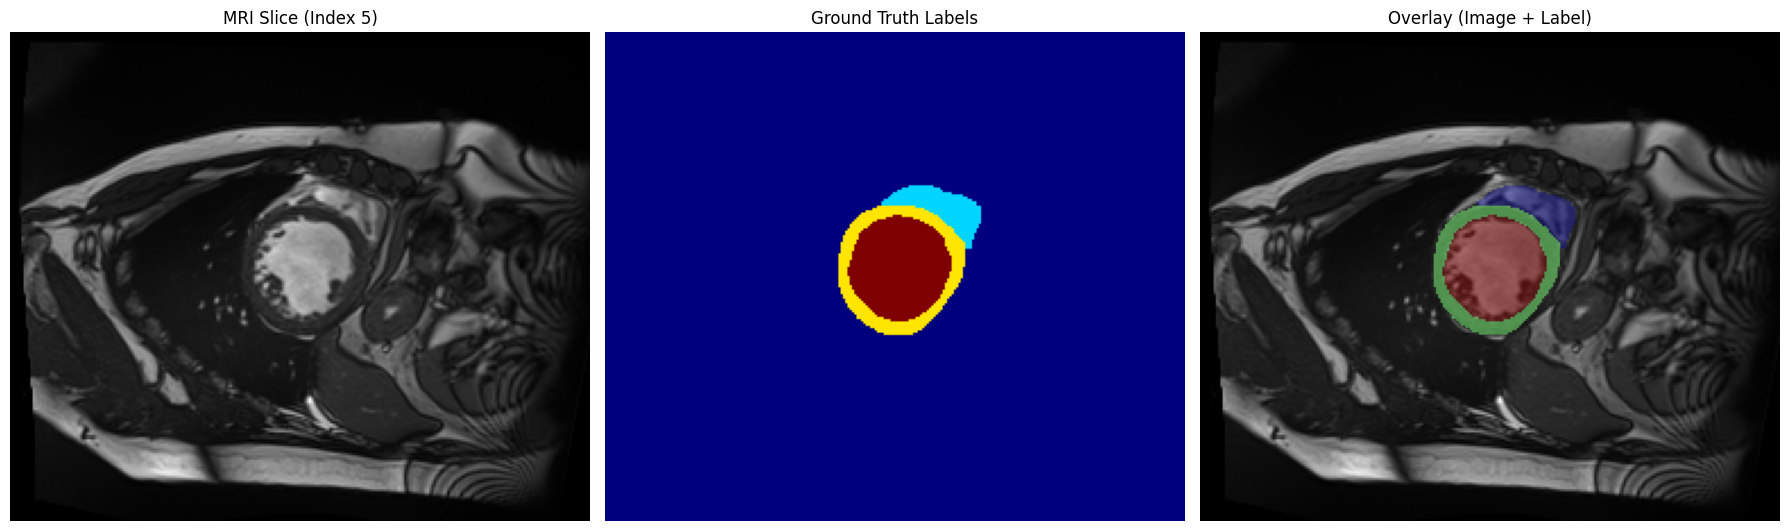

In [43]:
import matplotlib.pyplot as plt

def plot_slice_with_label(img_data, label_data, slice_idx=None):
    if slice_idx is None:
        slice_idx = img_data.shape[2] // 2 # Pick the middle slice
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Original Image Slice
    axes[0].imshow(img_data[:, :, slice_idx], cmap='gray')
    axes[0].set_title(f'MRI Slice (Index {slice_idx})')
    axes[0].axis('off')
    
    # 2. Label Map Slice
    axes[1].imshow(label_data[:, :, slice_idx], cmap='jet')
    axes[1].set_title('Ground Truth Labels')
    axes[1].axis('off')
    
    # 3. Overlay
    axes[2].imshow(img_data[:, :, slice_idx], cmap='gray')
    # Use alpha to make the label semi-transparent
    masked_label = np.ma.masked_where(label_data[:, :, slice_idx] == 0, label_data[:, :, slice_idx])
    axes[2].imshow(masked_label, cmap='jet', alpha=0.5)
    axes[2].set_title('Overlay (Image + Label)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Use the normalized image we created earlier and the label data
# Make sure img_norm_nonzero or your original img_ex is available
plot_slice_with_label(img_ex, label_data)


#### نکته فنی:

 من از np.ma.masked_where استفاده کردم تا بخش‌های پس‌زمینه (صفر) در ماسک شفاف شوند و فقط نواحی رنگی (قلب) روی تصویر MRI بیفتند.

##  استفاده از رنگ‌های ثابت برای labelها

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def plot_slice_with_fixed_labels(img_data, label_data, slice_idx=None):
    """
    Plot MRI, label mask, and overlay with fixed class colors.
    """
    if slice_idx is None:
        slice_idx = img_data.shape[2] // 2

    img_slice = img_data[:, :, slice_idx]
    label_slice = label_data[:, :, slice_idx]

    # Fixed colors: background, RV, MYO, LV
    class_colors = [
        "black",       # 0: Background
        "#00BFC4",     # 1: RV
        "#FFD700",     # 2: MYO
        "#D73027",     # 3: LV
    ]

    label_cmap = ListedColormap(class_colors)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # MRI
    axes[0].imshow(img_slice, cmap="gray")
    axes[0].set_title(f"MRI Slice {slice_idx}")

    # Label mask
    axes[1].imshow(label_slice, cmap=label_cmap, vmin=0, vmax=3)
    axes[1].set_title("Ground Truth Labels")

    # Overlay
    axes[2].imshow(img_slice, cmap="gray")

    masked_label = np.ma.masked_where(label_slice == 0, label_slice)
    axes[2].imshow(
        masked_label,
        cmap=label_cmap,
        vmin=0,
        vmax=3,
        alpha=0.45
    )
    axes[2].set_title("Overlay")

    for ax in axes:
        ax.axis("off")

    legend_items = [
        Patch(facecolor="#00BFC4", label="RV"),
        Patch(facecolor="#FFD700", label="MYO"),
        Patch(facecolor="#D73027", label="LV"),
    ]

    fig.legend(
        handles=legend_items,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.02)
    )

    plt.tight_layout()
    plt.show()


   slice_idx  background    rv  myo    lv  total_fg  has_label
0          0       55296     0    0     0         0      False
1          1       51669  1455  821  1351      3627       True
2          2       51506  1254  880  1656      3790       True
3          3       51607   998  939  1752      3689       True
4          4       51907   727  897  1765      3389       True
5          5       52274   512  888  1622      3022       True
6          6       52676   379  768  1473      2620       True
7          7       53270   227  670  1129      2026       True
8          8       53720   115  547   914      1576       True
9          9       54480    56  318   442       816       True

Slices with labels:
   slice_idx    rv  myo    lv  total_fg
1          1  1455  821  1351      3627
2          2  1254  880  1656      3790
3          3   998  939  1752      3689
4          4   727  897  1765      3389
5          5   512  888  1622      3022
6          6   379  768  1473      2620
7     

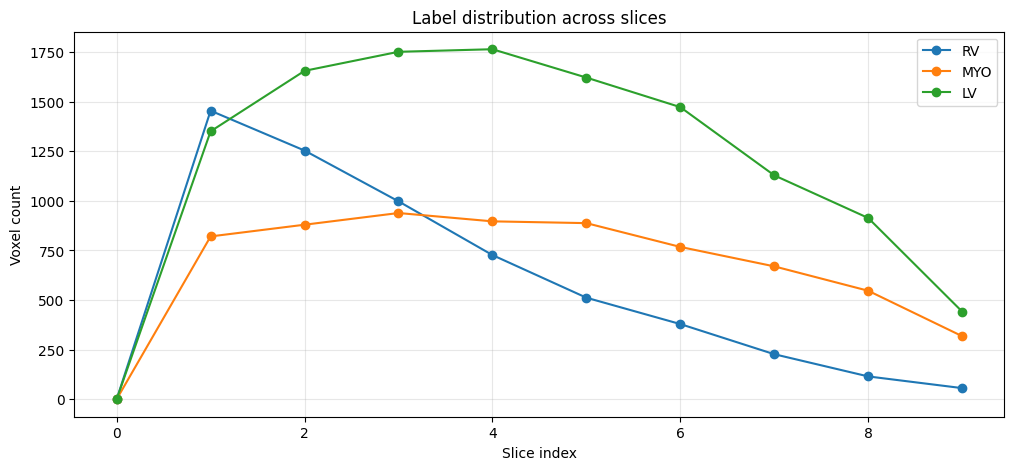

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_labels_per_slice(label_data: np.ndarray):
    """
    Analyze label counts for each slice.
    Returns a DataFrame with per-slice statistics.
    """
    rows = []

    num_slices = label_data.shape[2]

    for z in range(num_slices):
        sl = label_data[:, :, z]

        bg = np.sum(sl == 0)
        rv = np.sum(sl == 1)
        myo = np.sum(sl == 2)
        lv = np.sum(sl == 3)

        has_label = (rv + myo + lv) > 0

        rows.append({
            "slice_idx": z,
            "background": int(bg),
            "rv": int(rv),
            "myo": int(myo),
            "lv": int(lv),
            "total_fg": int(rv + myo + lv),
            "has_label": bool(has_label),
        })

    df = pd.DataFrame(rows)
    return df


def plot_slice_label_distribution(df: pd.DataFrame):
    """
    Plot label area per slice.
    """
    plt.figure(figsize=(12, 5))

    plt.plot(df["slice_idx"], df["rv"], marker="o", label="RV")
    plt.plot(df["slice_idx"], df["myo"], marker="o", label="MYO")
    plt.plot(df["slice_idx"], df["lv"], marker="o", label="LV")

    plt.xlabel("Slice index")
    plt.ylabel("Voxel count")
    plt.title("Label distribution across slices")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


df_slices = analyze_labels_per_slice(label_data)

print(df_slices)
print("\nSlices with labels:")
print(df_slices[df_slices["has_label"]][["slice_idx", "rv", "myo", "lv", "total_fg"]])

plot_slice_label_distribution(df_slices)
